In [2]:
from pprint import pprint

from shapely import geometry
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import xarray as xr
from distributed import LocalCluster
import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr
import zarr
import dask.array as da

from modules.utils import to_km2, plot_rgb_ndvi
from modules.data_load import get_epsg_from_first_band, load_sentinel_data, load_sentinel_scl, validate_scl

Setup


In [3]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.633501, 51.611195, 10.787234, 51.698098]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])


catalog = Client.open("https://stac.core.eopf.eodc.eu")

CloudCover is in properties, so we can select it from here.

In [4]:
years = range(2019, 2026)


r10m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_10m",
    max_cloud_cover=30
)
r10m

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 88kB 600005 600015 600025 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [5]:

r20m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_20m",
    max_cloud_cover=30
)
r20m

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.Dataset> Size: 14GB
Dimensions:      (time: 6, y: 5490, x: 5490)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 44kB 600010 600030 600050 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [6]:
scl20m = load_sentinel_scl(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SCL_20m",
    max_cloud_cover=30
)
scl20m

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.Dataset> Size: 181MB
Dimensions:  (time: 6, y: 5490, x: 5490)
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 2025-08...
Dimensions without coordinates: y, x
Data variables:
    scl      (time, y, x) uint8 181MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [7]:
epsg = get_epsg_from_first_band(r10m)

bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels


In [8]:
factor = 1
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m.sel()

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 6, y: 10980, x: 10980)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 88kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 6GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

Problem: Maybe the data we are using is obstructed by clouds e.g. and is being thrown out of the Mask?

#H2
WIP

In [9]:
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-06-01", f"{year}-08-30"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item to get better images.
    best_item = min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

    print(f"{year}: selected item with cloud cover = {best_item.properties.get("eo:cloud_cover", "unknown")}%")

    return best_item

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
scl_datasets = []


for item in items:
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    scl_da = scl_da.expand_dims(time=[pd.to_datetime(item.datetime).tz_localize(None)])
    scl_datasets.append(scl_da)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
scl20m = xr.concat(scl_datasets, dim="time", join="outer")
scl20m

2019: selected item with cloud cover = 0.006149%
2020: selected item with cloud cover = 1.216421%
2021: selected item with cloud cover = 9.860844%
2022: selected item with cloud cover = 0.001319%
2023: selected item with cloud cover = 0.294418%
2025: selected item with cloud cover = 0.002405%


<xarray.DataArray 'scl' (time: 6, y: 5490, x: 5490)> Size: 181MB
dask.array<concatenate, shape=(6, 5490, 5490), dtype=uint8, chunksize=(1, 915, 915), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 2025-08...
Dimensions without coordinates: y, x

In [10]:
target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    scl20m
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)

scl_100m

<xarray.DataArray 'scl' (time: 6, y: 10980, x: 10980)> Size: 6GB
dask.array<rechunk-merge, shape=(6, 10980, 10980), dtype=float64, chunksize=(1, 1830, 1830), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 88kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0

In [11]:

valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask) # Applying the mask
valid_r100m = r100m

In [12]:
mask_ratio = (~valid_mask).sum() / valid_mask.size
print(f"Fraction of pixels masked: {mask_ratio.values:.2%}") #TODO: Masking not working correctly, so we are skippig that. Currently, mask is all true, which can't really be correct.

Fraction of pixels masked: 0.00%


Result: Too little pixels removed for it to mess up the data that much.


In [13]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
reflectances_r100m = valid_r100m

#def scale_band(da):
#    attrs = da.attrs.get("_eopf_attrs", {})
#    #scale = attrs.get("scale_factor", 1.0)
#    offset = attrs.get("add_offset", 0.0)
#    #return da * scale + offset
#    return da + offset

#reflectances_r100m = xr.Dataset({
#    band: scale_band(valid_r100m[band])
#    for band in ["b02", "b04", "b08"]
#})

reflectances_r100m["ndvi"] = (reflectances_r100m.b08 - reflectances_r100m.b04) / (reflectances_r100m.b08 + reflectances_r100m.b04)

#TODO: Take EPSG from satellite data
#TODO: Check, whether every offset and scale matches.

cloudless_bands_ndvi = reflectances_r100m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

ndvi_region = region["ndvi"].compute()

yearly_ds = (
    reflectances_r100m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 258MB
Dimensions:      (year: 6, y: 991, x: 1086)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 8kB 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 9kB 6.129e+05 6.129e+05 ... 6.237e+05 6.237e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b03          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b04          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b08          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    ndvi         (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>

In [14]:
#NDVI for selected region, seems to be more optimal than before.
ndvi_region.min().item(), ndvi_region.max().item(), ndvi_region.mean().item()

(-0.3299232736572889, 0.9915453264443399, 0.8257973365486208)

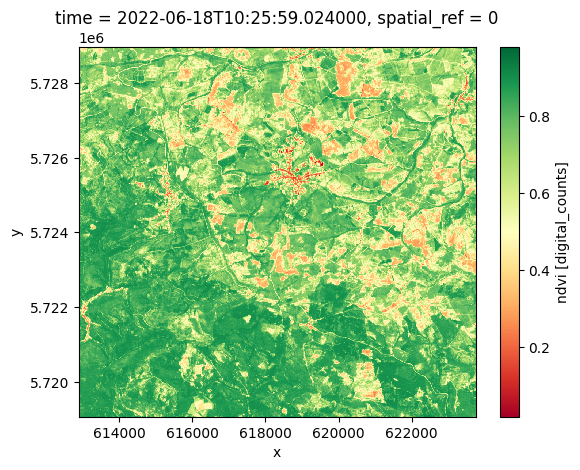

In [15]:
reflectances_r100m.ndvi.isel(time=3).sel(x=x_slice, y=y_slice).plot(
    cmap="RdYlGn"
)

In [16]:
import matplotlib.pyplot as plt



In [17]:
year = 2020
region = yearly_ds.sel(year=year)

region

<xarray.Dataset> Size: 43MB
Dimensions:      (y: 991, x: 1086)
Coordinates:
  * y            (y) float64 8kB 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 9kB 6.129e+05 6.129e+05 ... 6.237e+05 6.237e+05
    spatial_ref  int64 8B 0
    year         int64 8B 2020
Data variables:
    b02          (y, x) float64 9MB dask.array<chunksize=(215, 541), meta=np.ndarray>
    b03          (y, x) float64 9MB dask.array<chunksize=(215, 541), meta=np.ndarray>
    b04          (y, x) float64 9MB dask.array<chunksize=(215, 541), meta=np.ndarray>
    b08          (y, x) float64 9MB dask.array<chunksize=(215, 541), meta=np.ndarray>
    ndvi         (y, x) float64 9MB dask.array<chunksize=(215, 541), meta=np.ndarray>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0403..1.54].


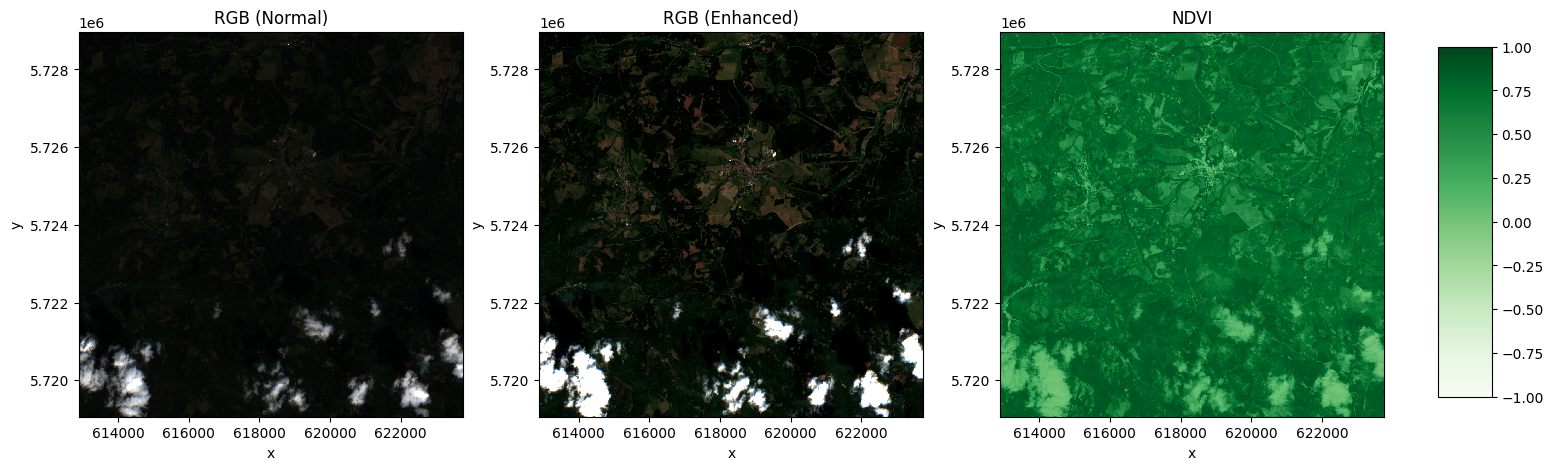

In [18]:
plot_rgb_ndvi(region, x_slice, y_slice)

In [19]:
yearly_ds

<xarray.Dataset> Size: 258MB
Dimensions:      (year: 6, y: 991, x: 1086)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 8kB 5.729e+06 5.729e+06 ... 5.719e+06 5.719e+06
  * x            (x) float64 9kB 6.129e+05 6.129e+05 ... 6.237e+05 6.237e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b03          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b04          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    b08          (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>
    ndvi         (year, y, x) float64 52MB dask.array<chunksize=(1, 215, 541), meta=np.ndarray>

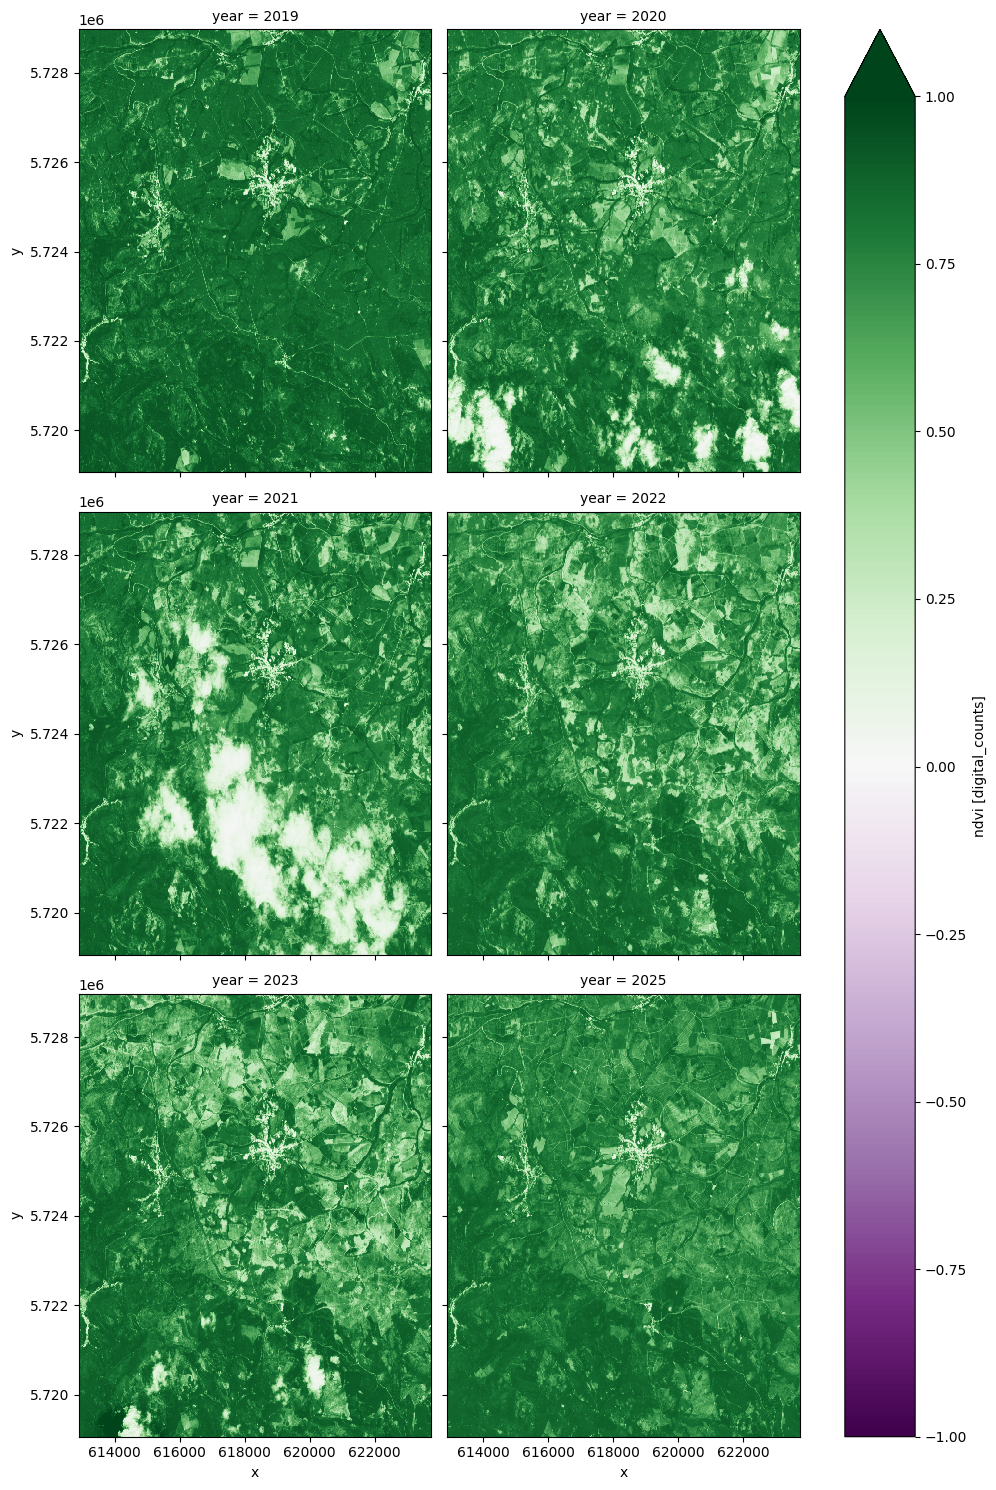

In [20]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(2018, 2025)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [21]:
yearly_ds.ndvi.values

array([[[0.85192698, 0.85477416, 0.84730379, ..., 0.91536547,
         0.91666667, 0.91746328],
        [0.85679612, 0.85641605, 0.84979424, ..., 0.91674551,
         0.91575092, 0.92484342],
        [0.86557569, 0.85452526, 0.85606874, ..., 0.92175274,
         0.91962617, 0.92      ],
        ...,
        [0.91225738, 0.91309161, 0.92049561, ..., 0.75979112,
         0.75919056, 0.77565061],
        [0.89767442, 0.90208078, 0.89280426, ..., 0.73132566,
         0.78977821, 0.77827051],
        [0.90337894, 0.8974359 , 0.86030429, ..., 0.78169791,
         0.78535354, 0.80549369]],

       [[0.78929188, 0.79389313, 0.78014657, ..., 0.86612102,
         0.86485753, 0.86269903],
        [0.7799308 , 0.80169972, 0.78120978, ..., 0.87521465,
         0.87130435, 0.87147229],
        [0.78794179, 0.79906853, 0.7819083 , ..., 0.8633368 ,
         0.86770428, 0.86236194],
        ...,
        [0.87361419, 0.8741343 , 0.87476485, ..., 0.75630769,
         0.76404864, 0.7640678 ],
        [0.8

In [22]:
import numpy as np
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7


#TODO: Remove resolution variable in favor of slice-size
resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([9674.03, 7572.42, 6538.41, 6989.29, 6652.01, 8395.07])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

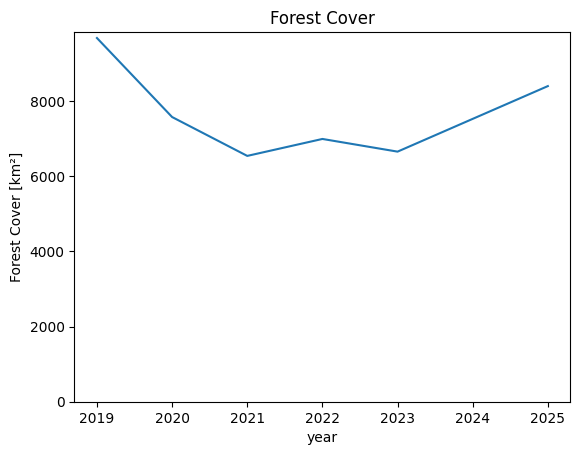

In [23]:
forest_area_km2.load() #Lazy loading
forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);